<center><u><H1>Perceptron with Scikit-Learn</H1></u></center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%matplotlib inline

## Loading data:

In [2]:
iris = load_iris()

In [3]:
X=iris.data[:,[2,3]]
y=iris.target

## Preprocessing data:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=2018)

In [5]:
sc = StandardScaler()

In [6]:
X_std = sc.fit_transform(X)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## Creating a Perceptron model:

In [7]:
p = Perceptron(penalty='l2', alpha=0.001, eta0=0.01, max_iter=1000)

In [8]:
p.fit(X_train_std, y_train)
#penalty : None, ‘l2’ or ‘l1’ or ‘elasticnet’
#alpha : regularization parameter
#eta0 : learning rate
#max_iter : maximum number of iterations
#shuffle : True(default) Whether to shuffle samples in each iteration

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


## Metrics:

In [9]:
p_pred = p.predict(X_test_std)

In [10]:
print("Accuracy Score:", accuracy_score(y_test,p_pred))

Accuracy Score: 0.8222222222222222


In [11]:
print("Confusion Matrix:\n", confusion_matrix(y_test,p_pred))

Confusion Matrix:
 [[18  0  0]
 [ 2  9  0]
 [ 0  6 10]]


In [12]:
print("Classification Report:\n", classification_report(y_test,p_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       0.60      0.82      0.69        11
           2       1.00      0.62      0.77        16

    accuracy                           0.82        45
   macro avg       0.83      0.81      0.80        45
weighted avg       0.86      0.82      0.82        45



## Cross Validation:

In [13]:
cross_val_score(p, X_std, y, cv=10)

array([1.        , 0.66666667, 0.66666667, 0.73333333, 0.66666667,
       0.66666667, 0.8       , 0.93333333, 0.66666667, 1.        ])

## Plotting Decision Boundaries:

In [14]:
import Plotting_Decision_Boundaries as pdb

C:\Prasad\Learnings\Python\Python-Training\NeuralNetworks\Plotting_Decision_Boundaries.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == item, 0], y=X[y == item, 1],alpha=0.8, c=cmap(index),


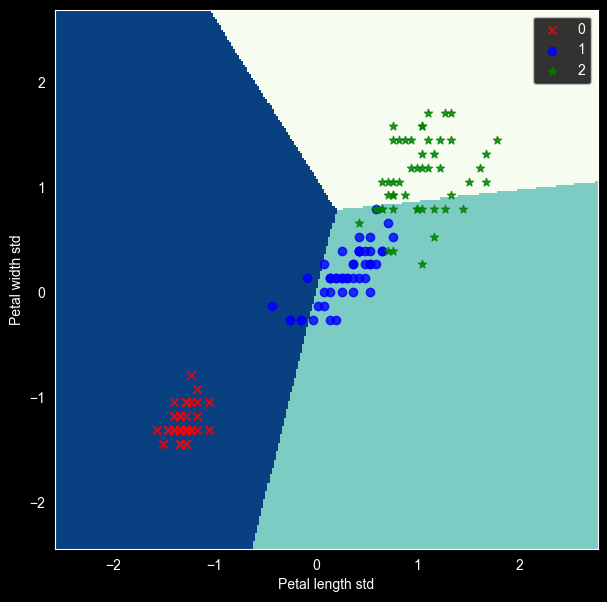

In [15]:
pdb.printing_db(X=X_std,y=y,model=p)

## Reference: 
http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html